In [1]:
import pandas as pd

###  load file 

In [2]:
df=pd.read_csv("C:\pdoc\data\house_prices.csv")

In [3]:
df

,Unnamed: 0,property_type,price,location,city,baths,purpose,bedrooms,Area_in_Marla
0,0,Flat,10000000,G-10,Islamabad,2,For Sale,2,4.0
1,1,Flat,6900000,E-11,Islamabad,3,For Sale,3,5.6
2,2,House,16500000,G-15,Islamabad,6,For Sale,5,8.0
3,3,House,43500000,Bani Gala,Islamabad,4,For Sale,4,40.0
4,4,House,7000000,DHA Defence,Islamabad,3,For Sale,3,8.0
...,...,...,...,...,...,...,...,...,...
99494,168435,Flat,7500000,Bahria Town Karachi,Karachi,3,For Sale,3,8.0
99495,168436,House,8800000,Bahria Town Karachi,Karachi,4,For Sale,3,8.0
99496,168438,House,14000000,Bahria Town Karachi,Karachi,3,For Sale,3,8.0
99497,168439,House,14000000,Bahria Town Karachi,Karachi,4,For Sale,4,14.0


In [4]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import classification_report,ConfusionMatrixDisplay

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99499 entries, 0 to 99498
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     99499 non-null  int64  
 1   property_type  99499 non-null  object 
 2   price          99499 non-null  int64  
 3   location       99499 non-null  object 
 4   city           99499 non-null  object 
 5   baths          99499 non-null  int64  
 6   purpose        99499 non-null  object 
 7   bedrooms       99499 non-null  int64  
 8   Area_in_Marla  99499 non-null  float64
dtypes: float64(1), int64(4), object(4)
memory usage: 6.8+ MB


In [6]:
df=df.drop(['Unnamed: 0'],axis=1)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99499 entries, 0 to 99498
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  99499 non-null  object 
 1   price          99499 non-null  int64  
 2   location       99499 non-null  object 
 3   city           99499 non-null  object 
 4   baths          99499 non-null  int64  
 5   purpose        99499 non-null  object 
 6   bedrooms       99499 non-null  int64  
 7   Area_in_Marla  99499 non-null  float64
dtypes: float64(1), int64(3), object(4)
memory usage: 6.1+ MB


In [8]:
df["property_type"].value_counts()

House            58169
Flat             26658
Upper Portion     8539
Lower Portion     5549
Penthouse          255
Room               241
Farm House          88
Name: property_type, dtype: int64

In [9]:
df["property_type"]=df["property_type"].replace({"House":0,"Flat":1,"Upper Portion":2,"Lower Portion":3,"Penthouse":4,"Room":5,"Farm House":6})

In [10]:
df["city"].value_counts()

Karachi       37066
Lahore        26221
Islamabad     22243
Rawalpindi    11738
Faisalabad     2231
Name: city, dtype: int64

In [11]:
df["city"]=df["city"].replace({"Karachi":0,"Lahore":1,"Islamabad":2,"Rawalpindi":3,"Faisalabad":4})

###  convert catagorical data into numaric value 

In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:
encoder=LabelEncoder()

In [14]:
df["location"]=encoder.fit_transform(df["location"])

In [15]:
df["purpose"]=encoder.fit_transform(df["purpose"])

In [16]:
df.head()

,property_type,price,location,city,baths,purpose,bedrooms,Area_in_Marla
0,1,10000000,452,2,2,1,2,4.0
1,1,6900000,382,2,3,1,3,5.6
2,0,16500000,457,2,6,1,5,8.0
3,0,43500000,198,2,4,1,4,40.0
4,0,7000000,327,2,3,1,3,8.0


###  partition of data 

In [17]:
y=df["price"]
x=df.drop("price",axis=1)

In [18]:
x

,property_type,location,city,baths,purpose,bedrooms,Area_in_Marla
0,1,452,2,2,1,2,4.0
1,1,382,2,3,1,3,5.6
2,0,457,2,6,1,5,8.0
3,0,198,2,4,1,4,40.0
4,0,327,2,3,1,3,8.0
...,...,...,...,...,...,...,...
99494,1,189,0,3,1,3,8.0
99495,0,189,0,4,1,3,8.0
99496,0,189,0,3,1,3,8.0
99497,0,189,0,4,1,4,14.0


In [19]:
df

,property_type,price,location,city,baths,purpose,bedrooms,Area_in_Marla
0,1,10000000,452,2,2,1,2,4.0
1,1,6900000,382,2,3,1,3,5.6
2,0,16500000,457,2,6,1,5,8.0
3,0,43500000,198,2,4,1,4,40.0
4,0,7000000,327,2,3,1,3,8.0
...,...,...,...,...,...,...,...,...
99494,1,7500000,189,0,3,1,3,8.0
99495,0,8800000,189,0,4,1,3,8.0
99496,0,14000000,189,0,3,1,3,8.0
99497,0,14000000,189,0,4,1,4,14.0


In [20]:
y

0        10000000
1         6900000
2        16500000
3        43500000
4         7000000
           ...   
99494     7500000
99495     8800000
99496    14000000
99497    14000000
99498     9000000
Name: price, Length: 99499, dtype: int64

###  training the modle 

In [21]:
from sklearn.model_selection import train_test_split

In [47]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

In [23]:
df.info

<bound method DataFrame.info of        property_type     price  location  city  baths  purpose  bedrooms  \
0                  1  10000000       452     2      2        1         2   
1                  1   6900000       382     2      3        1         3   
2                  0  16500000       457     2      6        1         5   
3                  0  43500000       198     2      4        1         4   
4                  0   7000000       327     2      3        1         3   
...              ...       ...       ...   ...    ...      ...       ...   
99494              1   7500000       189     0      3        1         3   
99495              0   8800000       189     0      4        1         3   
99496              0  14000000       189     0      3        1         3   
99497              0  14000000       189     0      4        1         4   
99498              0   9000000       189     0      3        1         3   

       Area_in_Marla  
0                4.0  
1        

In [24]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 69649 entries, 91301 to 84689
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  69649 non-null  int64  
 1   location       69649 non-null  int32  
 2   city           69649 non-null  int64  
 3   baths          69649 non-null  int64  
 4   purpose        69649 non-null  int32  
 5   bedrooms       69649 non-null  int64  
 6   Area_in_Marla  69649 non-null  float64
dtypes: float64(1), int32(2), int64(4)
memory usage: 3.7 MB


In [25]:
x_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 29850 entries, 62385 to 55465
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  29850 non-null  int64  
 1   location       29850 non-null  int32  
 2   city           29850 non-null  int64  
 3   baths          29850 non-null  int64  
 4   purpose        29850 non-null  int32  
 5   bedrooms       29850 non-null  int64  
 6   Area_in_Marla  29850 non-null  float64
dtypes: float64(1), int32(2), int64(4)
memory usage: 1.6 MB


###  linearRegression module 

In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
model=LinearRegression()

In [28]:
model.fit(x_train,y_train)

LinearRegression()

In [29]:
df.head()

,property_type,price,location,city,baths,purpose,bedrooms,Area_in_Marla
0,1,10000000,452,2,2,1,2,4.0
1,1,6900000,382,2,3,1,3,5.6
2,0,16500000,457,2,6,1,5,8.0
3,0,43500000,198,2,4,1,4,40.0
4,0,7000000,327,2,3,1,3,8.0


###  predict the data 

In [30]:
model.predict([[0,23,1,3,1,2,7]])

array([12345817.78883538])

In [31]:
y_pred=model.predict(x_test)

###  Mean_absolute_error

In [32]:
from sklearn.metrics import mean_absolute_error

In [33]:
mean_absolute_error(y_pred,y_test)

5119206.545376079

###  # KNN Classifier

In [34]:
# KNN Classifier
from sklearn.neighbors import KNeighborsClassifier
data=KNeighborsClassifier(n_neighbors=1)
data.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=1)

In [35]:
# Predict and evaluate
model.predict([[0,23,1,3,1,2,7]])

array([12345817.78883538])

In [36]:
y_pred=model.predict(x_test)

In [37]:
y_pred

array([12904591.92569899, 13308875.28597481,  7825095.87382878, ...,
       13485471.17296156, 18812497.12459949, 17701628.60361339])

In [38]:
df

,property_type,price,location,city,baths,purpose,bedrooms,Area_in_Marla
0,1,10000000,452,2,2,1,2,4.0
1,1,6900000,382,2,3,1,3,5.6
2,0,16500000,457,2,6,1,5,8.0
3,0,43500000,198,2,4,1,4,40.0
4,0,7000000,327,2,3,1,3,8.0
...,...,...,...,...,...,...,...,...
99494,1,7500000,189,0,3,1,3,8.0
99495,0,8800000,189,0,4,1,3,8.0
99496,0,14000000,189,0,3,1,3,8.0
99497,0,14000000,189,0,4,1,4,14.0


###  graph

In [39]:
import matplotlib.pyplot as plt

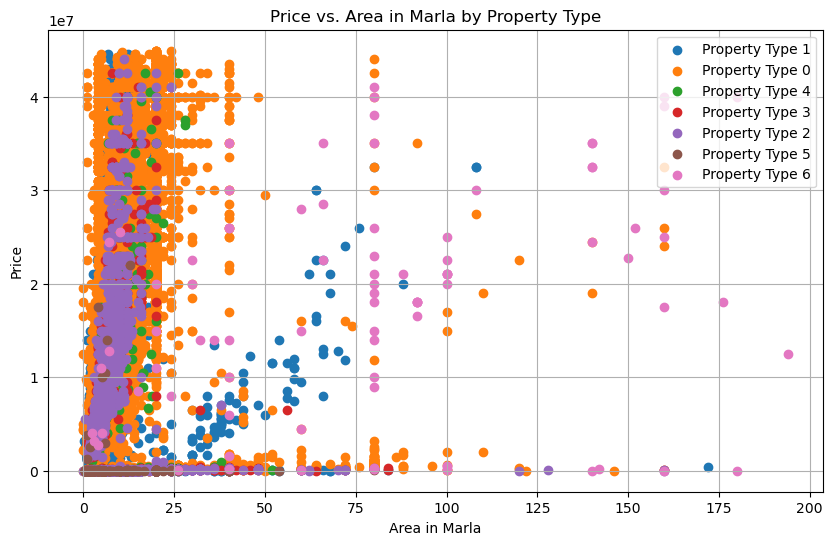

In [40]:
plt.figure(figsize=(10, 6))
for property_type in df['property_type'].unique():
    subset = df[df['property_type'] == property_type] 
    plt.scatter(subset['Area_in_Marla'], subset['price'],label=f'Property Type {property_type}')

plt.title('Price vs. Area in Marla by Property Type')
plt.xlabel('Area in Marla')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [41]:
import seaborn as sns

<AxesSubplot:xlabel='Area_in_Marla', ylabel='price'>

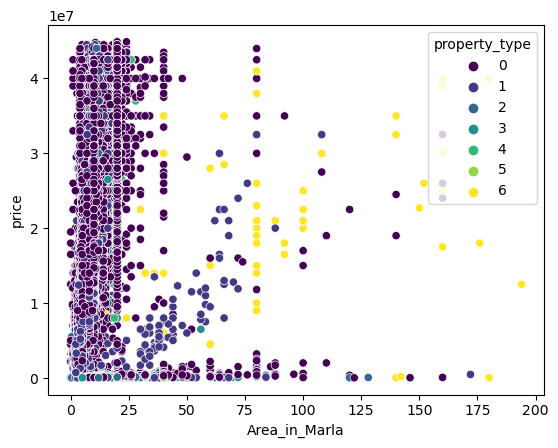

In [42]:
# Create the scatter plot

sns.scatterplot(data=df, x='Area_in_Marla', y='price', hue='property_type', palette='viridis')

###  DecisionTreeClassifier

In [43]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [44]:
clf = DecisionTreeClassifier()
clf.fit(x_train, y_train)

DecisionTreeClassifier()

In [45]:
y_pred = clf.predict(x_test)
y_pred

array([13500000,  9500000,  4700000, ...,  8500000, 16500000, 20000000],
      dtype=int64)

### accuracy 

In [46]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 0.13242881072026802
